In [1]:

import duckdb
import pandas as pd
import matplotlib.pyplot as plt

con = duckdb.connect("healthcare.duckdb")

con.execute("PRAGMA threads=8")
con.execute("SET memory_limit='6GB'")

import matplotlib.font_manager as fm

font_path = "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc"

fm.fontManager.addfont(font_path)

font_name = fm.FontProperties(fname=font_path).get_name()

plt.rcParams["font.family"] = font_name
plt.rcParams["axes.unicode_minus"] = False

print(font_name)

Noto Sans CJK JP


In [2]:
# import duckdb
# import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 0. 최근 3개년 자동 확인
# ============================================================

years = con.execute("""
    SELECT DISTINCT
        CAST(LEFT(CAST(diagYm AS VARCHAR), 4) AS INTEGER) AS year
    FROM mefi_sick
    WHERE diagYm IS NOT NULL
    ORDER BY year DESC
    LIMIT 3
""").df()["year"].tolist()

years = sorted(years)

y_old, y_mid, y_recent = years

print("분석연도:", years)


# ============================================================
# 1. 약효분류군별 연도별 사용액
# ============================================================

mefi_growth = con.execute(f"""
WITH yearly AS (
    SELECT
        meftDivNo,
        MAX(meftDivNoNm) AS meftDivNoNm,

        CAST(
            LEFT(CAST(diagYm AS VARCHAR), 4)
            AS INTEGER
        ) AS year,

        SUM(msupUseAmt) AS usage_amt

    FROM mefi_sick

    WHERE CAST(
        LEFT(CAST(diagYm AS VARCHAR), 4)
        AS INTEGER
    ) BETWEEN {y_old} AND {y_recent}

    GROUP BY
        meftDivNo,
        CAST(
            LEFT(CAST(diagYm AS VARCHAR), 4)
            AS INTEGER
        )
),

pivoted AS (
    SELECT
        meftDivNo,
        MAX(meftDivNoNm) AS meftDivNoNm,

        SUM(
            CASE
                WHEN year = {y_old}
                THEN usage_amt ELSE 0
            END
        ) AS usage_old,

        SUM(
            CASE
                WHEN year = {y_mid}
                THEN usage_amt ELSE 0
            END
        ) AS usage_mid,

        SUM(
            CASE
                WHEN year = {y_recent}
                THEN usage_amt ELSE 0
            END
        ) AS usage_recent

    FROM yearly

    GROUP BY meftDivNo
)

SELECT
    meftDivNo,
    meftDivNoNm,

    usage_old,
    usage_mid,
    usage_recent,

    -- 최근 2년 성장액
    usage_recent - usage_old
        AS growth_amt,

    -- 억원
    (usage_recent - usage_old)
        / 100000000.0
        AS growth_amt_eok,

    -- 누적성장률
    CASE
        WHEN usage_old > 0
        THEN
            (usage_recent / usage_old - 1.0) * 100
        ELSE NULL
    END AS cumulative_growth_rate

FROM pivoted

WHERE usage_old > 0
""").df()


# ============================================================
# 2. 중앙값 계산
# ============================================================

median_growth_amt = (
    mefi_growth["growth_amt_eok"].median()
)

median_growth_rate = (
    mefi_growth["cumulative_growth_rate"].median()
)

print(
    f"\n성장액 중앙값: "
    f"{median_growth_amt:,.2f} 억원"
)

print(
    f"누적성장률 중앙값: "
    f"{median_growth_rate:,.2f}%"
)


# ============================================================
# 3. 4개 그룹 분류
# ============================================================

mefi_growth["segment"] = np.select(
    [
        (
            mefi_growth["growth_amt_eok"]
            > median_growth_amt
        )
        &
        (
            mefi_growth["cumulative_growth_rate"]
            > median_growth_rate
        ),

        (
            mefi_growth["growth_amt_eok"]
            <= median_growth_amt
        )
        &
        (
            mefi_growth["cumulative_growth_rate"]
            > median_growth_rate
        ),

        (
            mefi_growth["growth_amt_eok"]
            > median_growth_amt
        )
        &
        (
            mefi_growth["cumulative_growth_rate"]
            <= median_growth_rate
        )
    ],

    [
        "best",
        "rising",
        "mature"
    ],

    default="worse"
)


# ============================================================
# 4. 결과 확인
# ============================================================

print("\n=== 약효분류군 분류 결과 ===")

display(
    mefi_growth[
        [
            "meftDivNo",
            "meftDivNoNm",
            "growth_amt_eok",
            "cumulative_growth_rate",
            "segment"
        ]
    ]
    .sort_values(
        "growth_amt_eok",
        ascending=False
    )
)


print("\n=== 그룹별 개수 ===")

display(
    mefi_growth
    .groupby("segment")
    .size()
    .reset_index(name="n")
)

분석연도: [2020, 2021, 2022]

성장액 중앙값: 34.85 억원
누적성장률 중앙값: 5.51%

=== 약효분류군 분류 결과 ===


,meftDivNo,meftDivNoNm,growth_amt_eok,cumulative_growth_rate,segment
56,218,동맥경화용제,8081.139566,22.682116,best
31,232,소화성궤양용제,4079.244970,20.958988,best
5,396,당뇨병용제,3233.549136,16.905579,best
26,222,진해거담제,3194.658349,64.127694,best
86,214,혈압강하제,2871.725418,9.709718,best
...,...,...,...,...,...
33,821,합성마약,-294.171783,-12.035714,worse
4,439,기타의 조직세포의 치료 및 진단,-295.016867,-4.288212,worse
11,217,혈관확장제,-402.816877,-18.501014,worse
66,349,기타의 인공관류용제,-541.099080,-24.672687,worse



=== 그룹별 개수 ===


,segment,n
0,best,41
1,mature,8
2,rising,8
3,worse,41


In [3]:
# ============================================================
# 5. 그룹별 성장액 TOP 3
# ============================================================

segment_order = [
    "best",
    "rising",
    "mature",
    "worse"
]

top3 = (
    mefi_growth
    .sort_values(
        ["segment", "growth_amt_eok"],
        ascending=[True, False]
    )
    .groupby("segment", group_keys=False)
    .head(3)
    .copy()
)

top3 = (
    top3
    .sort_values(
        ["segment", "growth_amt_eok"],
        ascending=[True, False]
    )
)

print("\n=== 그룹별 성장액 TOP 3 ===")

display(
    top3[
        [
            "segment",
            "meftDivNo",
            "meftDivNoNm",
            "growth_amt_eok",
            "cumulative_growth_rate"
        ]
    ]
)


=== 그룹별 성장액 TOP 3 ===


,segment,meftDivNo,meftDivNoNm,growth_amt_eok,cumulative_growth_rate
56,best,218,동맥경화용제,8081.139566,22.682116
31,best,232,소화성궤양용제,4079.244970,20.958988
5,best,396,당뇨병용제,3233.549136,16.905579
12,mature,219,기타의 순환계용약,628.064606,5.227923
48,mature,421,항악성종양제,327.727420,0.864761
1,mature,113,항전간제,225.624643,5.374540
97,rising,255,비뇨생식기관용제(성병예방제 포함),31.034298,10.990807
80,rising,615,"주로 그람음성균,리케치아,비루스에 작용하는 것",15.694784,11.553764
78,rising,116,진훈제,14.572936,545.265045
16,worse,124,진경제,32.159618,4.688894


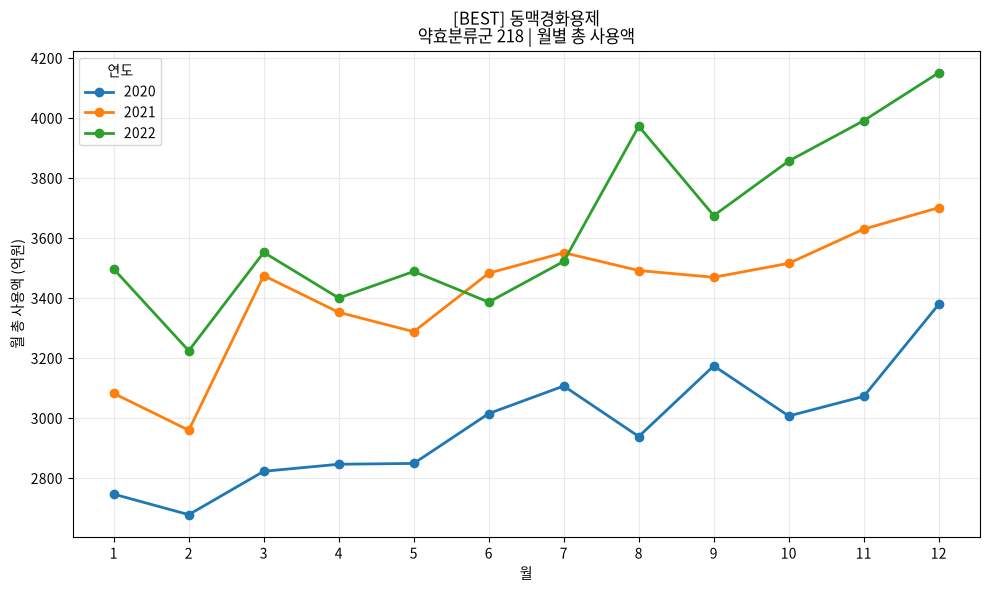

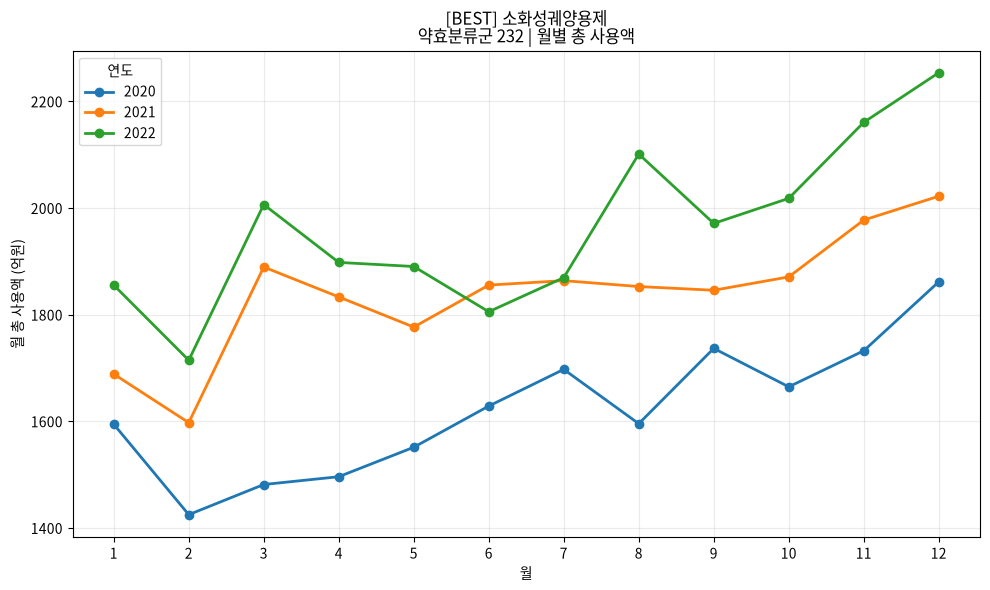

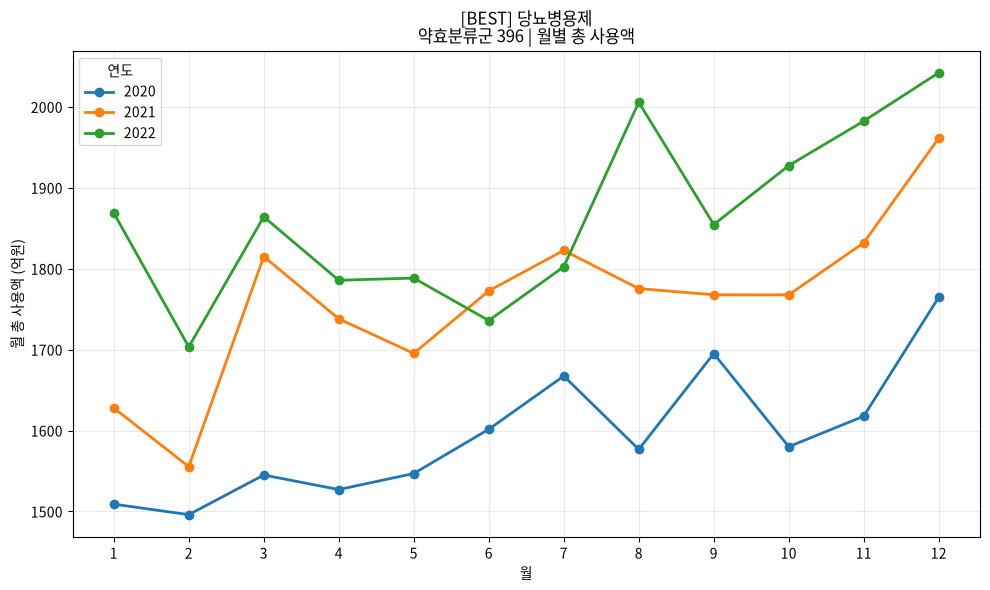

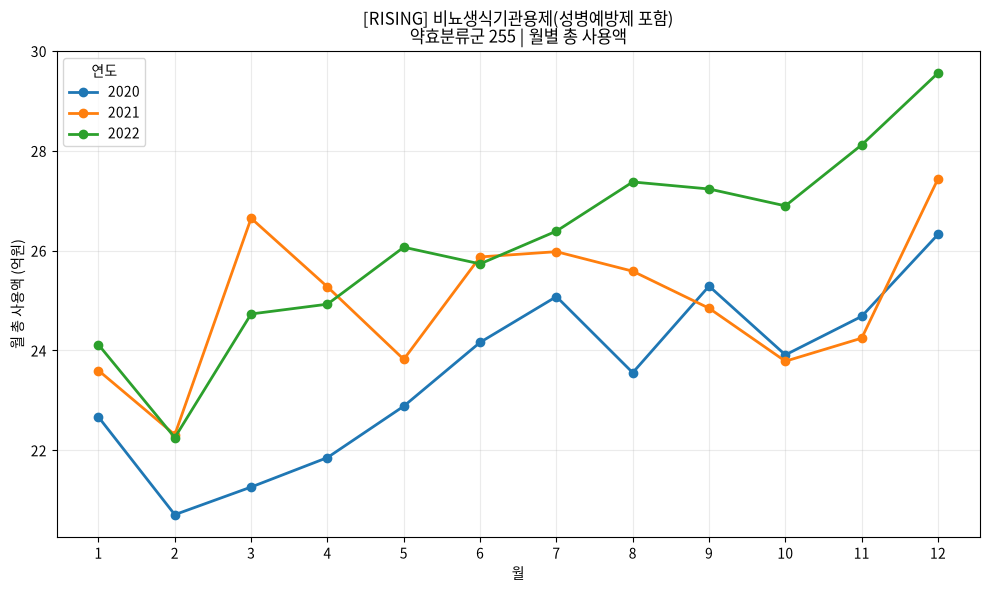

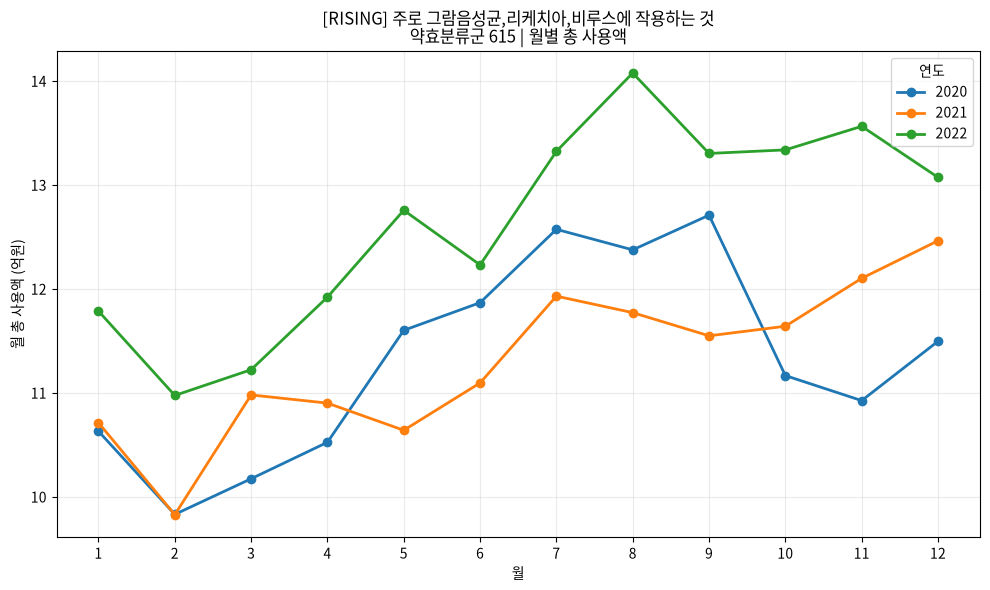

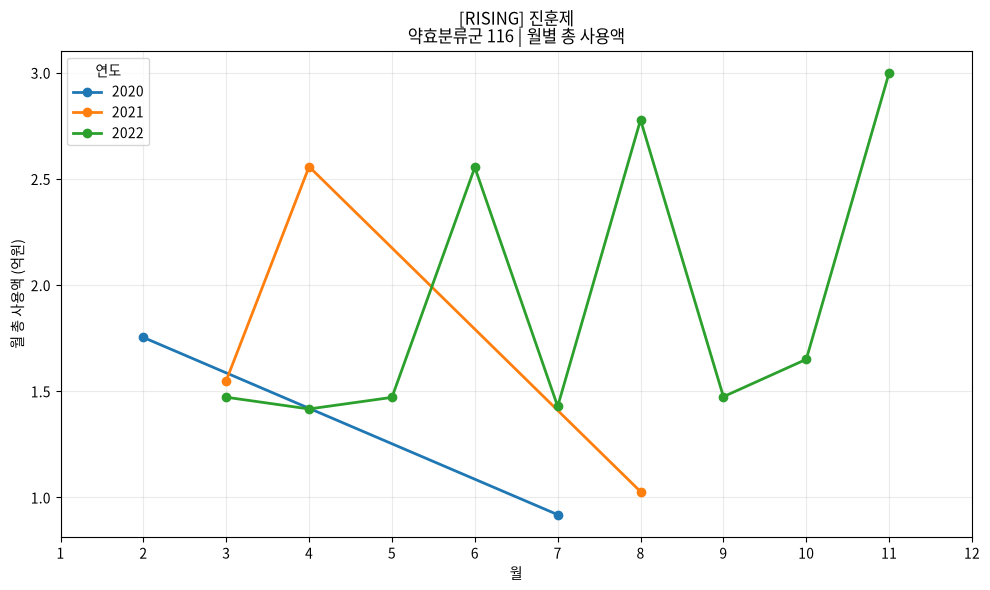

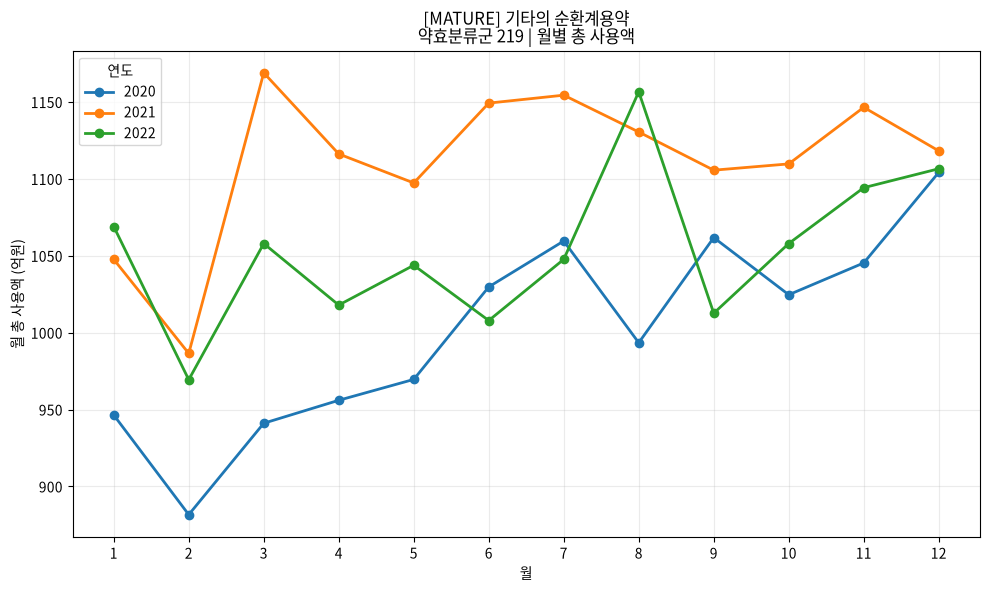

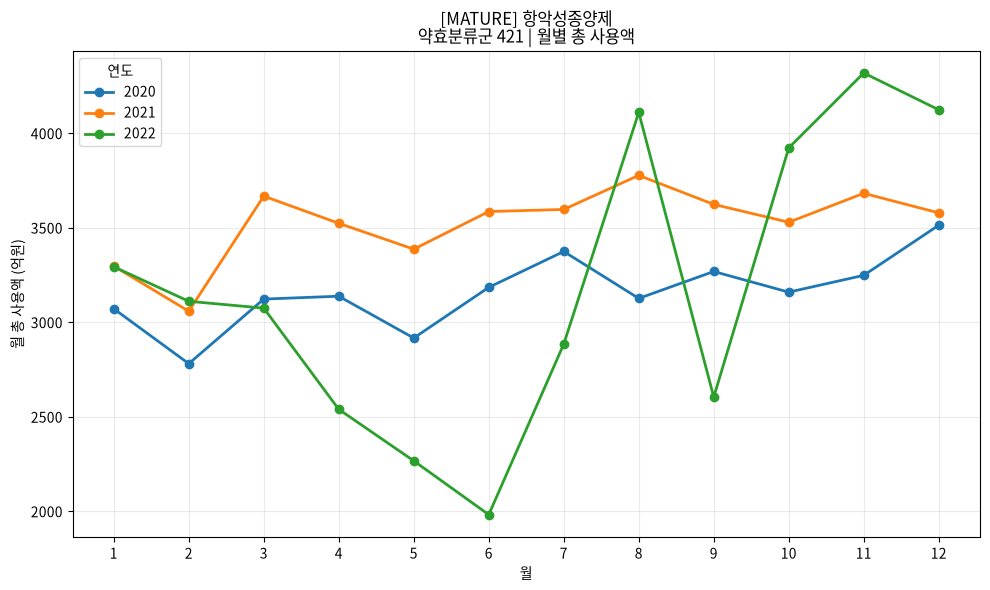

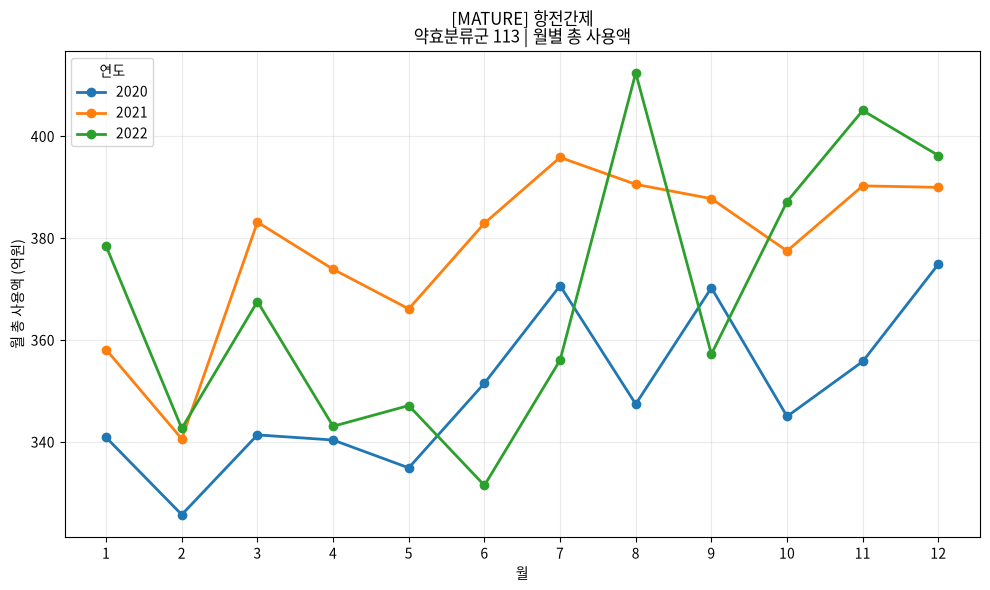

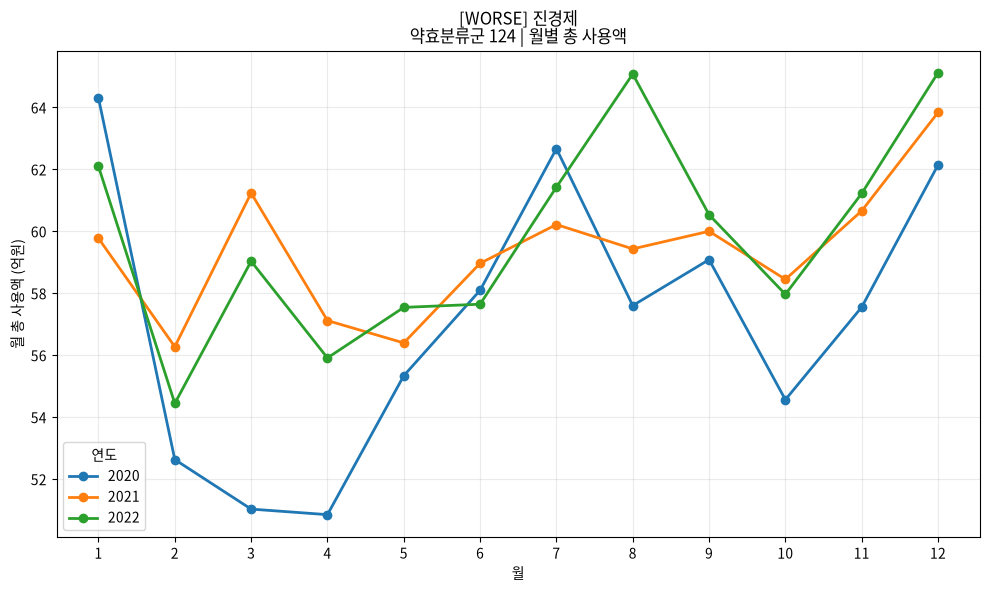

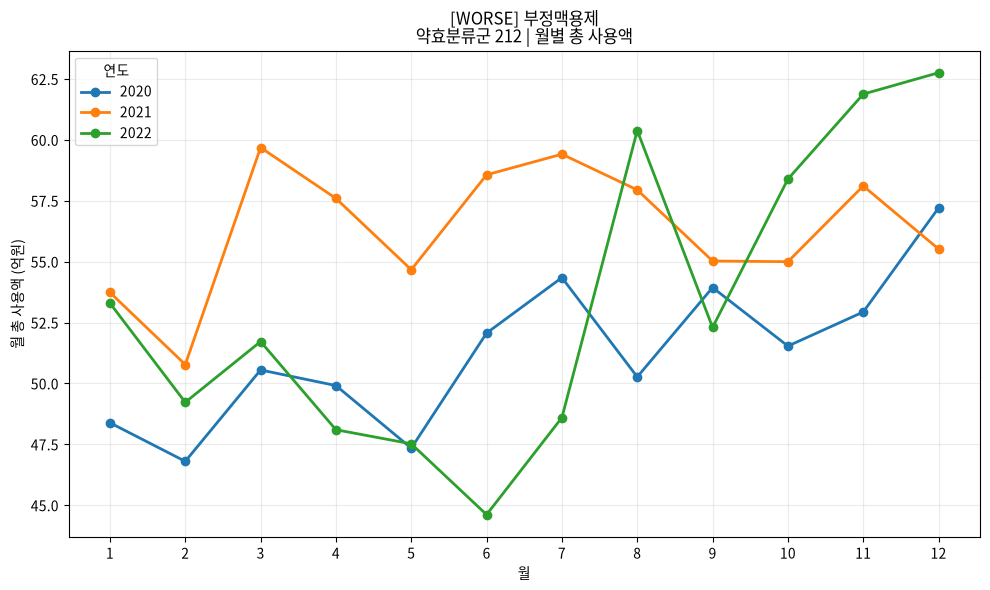

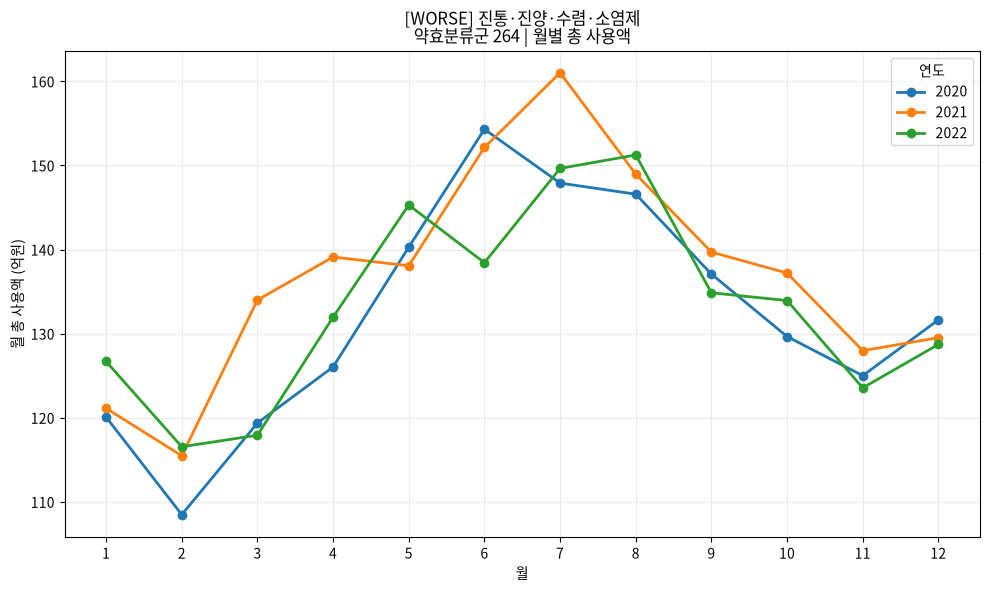

In [4]:
# ============================================================
# 6. TOP 12 약효분류군 코드
# ============================================================

top_codes = top3["meftDivNo"].tolist()

code_sql = ",".join(
    [
        "'" + str(x).replace("'", "''") + "'"
        for x in top_codes
    ]
)


# ============================================================
# 7. 월별 총 사용액
# ============================================================

monthly_usage = con.execute(f"""
SELECT
    CAST(
        LEFT(CAST(diagYm AS VARCHAR), 4)
        AS INTEGER
    ) AS year,

    CAST(
        RIGHT(
            CAST(diagYm AS VARCHAR),
            2
        )
        AS INTEGER
    ) AS month,

    meftDivNo,

    MAX(meftDivNoNm) AS meftDivNoNm,

    SUM(msupUseAmt) AS usage_amt,

    SUM(msupUseAmt)
        / 100000000.0
        AS usage_amt_eok

FROM mefi_sick

WHERE meftDivNo IN ({code_sql})

  AND CAST(
        LEFT(CAST(diagYm AS VARCHAR), 4)
        AS INTEGER
      )
      BETWEEN {y_old} AND {y_recent}

GROUP BY
    CAST(
        LEFT(CAST(diagYm AS VARCHAR), 4)
        AS INTEGER
    ),

    CAST(
        RIGHT(
            CAST(diagYm AS VARCHAR),
            2
        )
        AS INTEGER
    ),

    meftDivNo

ORDER BY
    meftDivNo,
    year,
    month
""").df()


# ============================================================
# 8. 월별 사용액 12개 그래프
# ============================================================

for segment in segment_order:

    segment_targets = (
        top3[
            top3["segment"] == segment
        ]
        .sort_values(
            "growth_amt_eok",
            ascending=False
        )
    )

    for _, row in segment_targets.iterrows():

        code = row["meftDivNo"]
        name = row["meftDivNoNm"]

        plot_df = monthly_usage[
            monthly_usage["meftDivNo"] == code
        ].copy()

        plt.figure(figsize=(10, 6))

        for year in years:

            tmp = (
                plot_df[
                    plot_df["year"] == year
                ]
                .sort_values("month")
            )

            plt.plot(
                tmp["month"],
                tmp["usage_amt_eok"],
                marker="o",
                linewidth=2,
                label=str(year)
            )

        plt.xlabel("월")

        plt.ylabel(
            "월 총 사용액 (억원)"
        )

        plt.title(
            f"[{segment.upper()}] {name}\n"
            f"약효분류군 {code} | 월별 총 사용액"
        )

        plt.xticks(range(1, 13))

        plt.legend(
            title="연도"
        )

        plt.grid(
            alpha=0.25
        )

        plt.tight_layout()

        plt.show()

In [5]:
# ============================================================
# 9. 12개 약효분류군의 연도별 12월-1월 사용액 차이
# ============================================================

dec_jan = (
    monthly_usage[
        monthly_usage["month"].isin([1, 12])
    ]
    .pivot_table(
        index=[
            "meftDivNo",
            "meftDivNoNm",
            "year"
        ],
        columns="month",
        values="usage_amt_eok",
        aggfunc="sum"
    )
    .reset_index()
)

dec_jan.columns.name = None

dec_jan = dec_jan.rename(
    columns={
        1: "jan_usage_eok",
        12: "dec_usage_eok"
    }
)

dec_jan["dec_minus_jan_eok"] = (
    dec_jan["dec_usage_eok"]
    -
    dec_jan["jan_usage_eok"]
)


# ============================================================
# 10. 3개년 평균
# ============================================================

dec_jan_summary = (
    dec_jan
    .groupby(
        [
            "meftDivNo",
            "meftDivNoNm"
        ],
        as_index=False
    )
    .agg(
        avg_dec_minus_jan_eok=(
            "dec_minus_jan_eok",
            "mean"
        )
    )
)


# ============================================================
# 11. 가장 큰 2개 / 가장 작은 2개
# ============================================================

largest2 = (
    dec_jan_summary
    .nlargest(
        2,
        "avg_dec_minus_jan_eok"
    )
    .assign(selection="largest")
)

smallest2 = (
    dec_jan_summary
    .nsmallest(
        2,
        "avg_dec_minus_jan_eok"
    )
    .assign(selection="smallest")
)

selected4 = pd.concat(
    [
        largest2,
        smallest2
    ],
    ignore_index=True
)


print(
    "\n=== 12월 - 1월 사용액 차이 기준 최종 4개 ==="
)

display(selected4)


=== 12월 - 1월 사용액 차이 기준 최종 4개 ===


,meftDivNo,meftDivNoNm,avg_dec_minus_jan_eok,selection
0,218,동맥경화용제,635.216350,largest
1,421,항악성종양제,517.976178,largest
2,615,"주로 그람음성균,리케치아,비루스에 작용하는 것",1.300843,smallest
3,124,진경제,1.642895,smallest
